# Task 2: Customer Segmentation — Mall Customers
K-Means clustering on Annual Income vs Spending Score | Best model: **K=5, Silhouette=0.5547**

## 1. Setup & Data Loading

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'Spending']

print("Shape:", df.shape)
print(df.describe())
print("Missing values:", df.isnull().sum().sum())

100%|██████████| 1.55k/1.55k [00:00<00:00, 561kB/s]

Extracting files...
Shape: (200, 5)
       CustomerID         Age      Income    Spending
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000   38.850000   60.560000   50.200000
std     57.879185   13.969007   26.264721   25.823522
min      1.000000   18.000000   15.000000    1.000000
25%     50.750000   28.750000   41.500000   34.750000
50%    100.500000   36.000000   61.500000   50.000000
75%    150.250000   49.000000   78.000000   73.000000
max    200.000000   70.000000  137.000000   99.000000
Missing values: 0


## 2. Exploratory Data Analysis

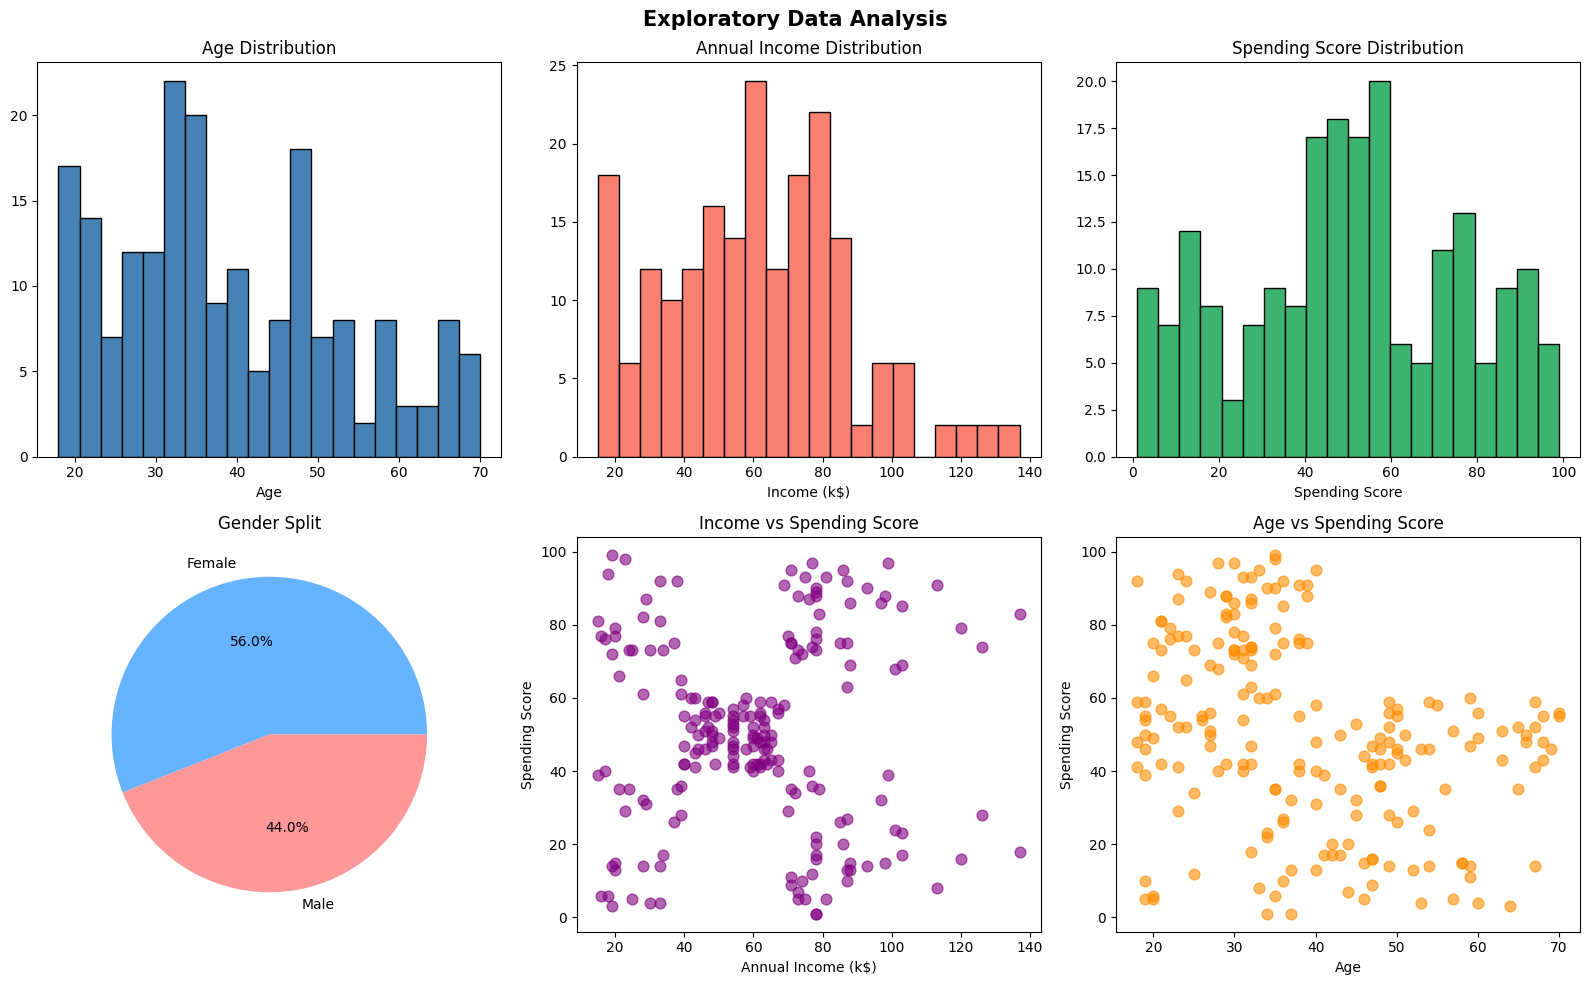

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

axes[0,1].hist(df['Income'], bins=20, color='salmon', edgecolor='black')
axes[0,1].set_title('Annual Income Distribution')
axes[0,1].set_xlabel('Income (k$)')

axes[0,2].hist(df['Spending'], bins=20, color='mediumseagreen', edgecolor='black')
axes[0,2].set_title('Spending Score Distribution')
axes[0,2].set_xlabel('Spending Score')

df['Gender'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%',
                                  colors=['#66b3ff','#ff9999'])
axes[1,0].set_title('Gender Split')
axes[1,0].set_ylabel('')

axes[1,1].scatter(df['Income'], df['Spending'], c='purple', alpha=0.6, s=60)
axes[1,1].set_title('Income vs Spending Score')
axes[1,1].set_xlabel('Annual Income (k$)')
axes[1,1].set_ylabel('Spending Score')

axes[1,2].scatter(df['Age'], df['Spending'], c='darkorange', alpha=0.6, s=60)
axes[1,2].set_title('Age vs Spending Score')
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Spending Score')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

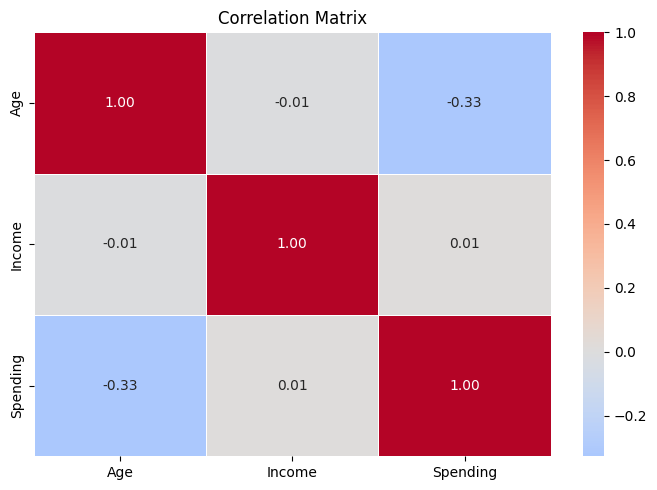

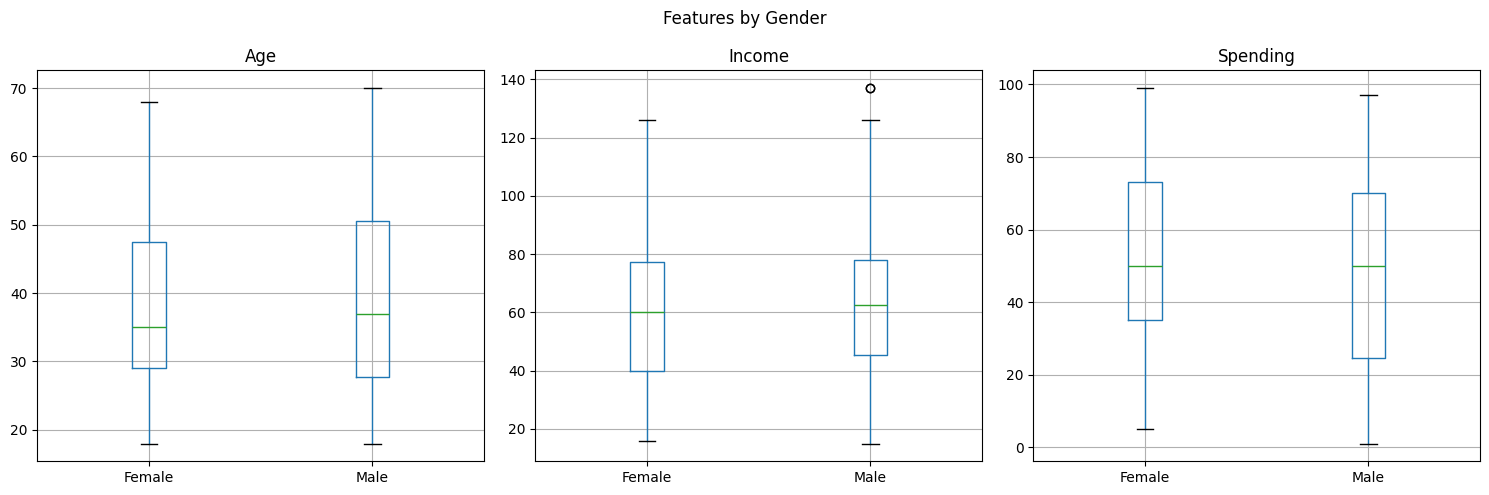

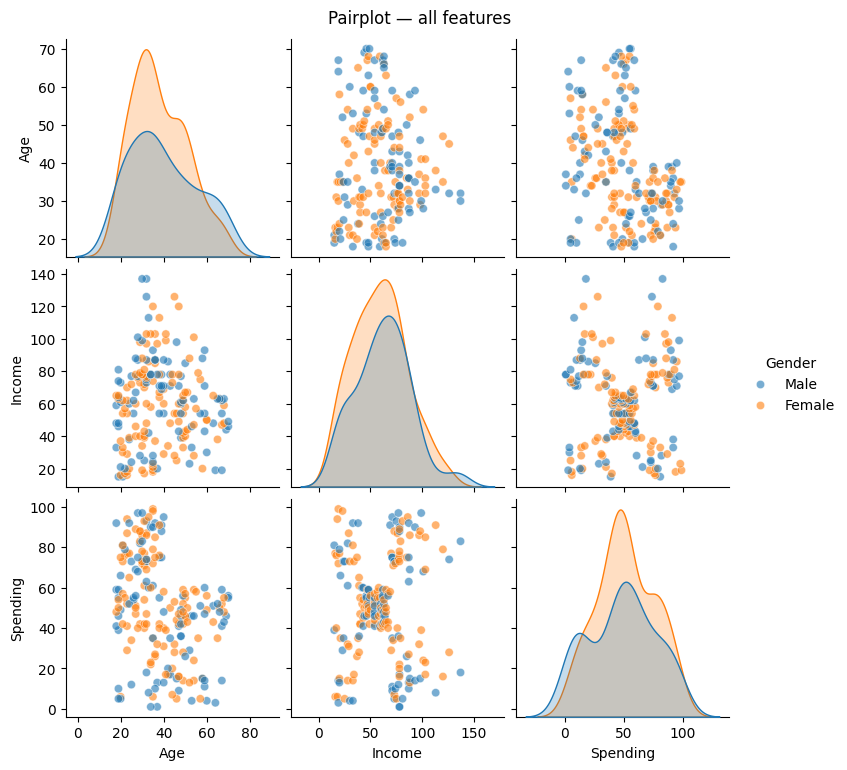

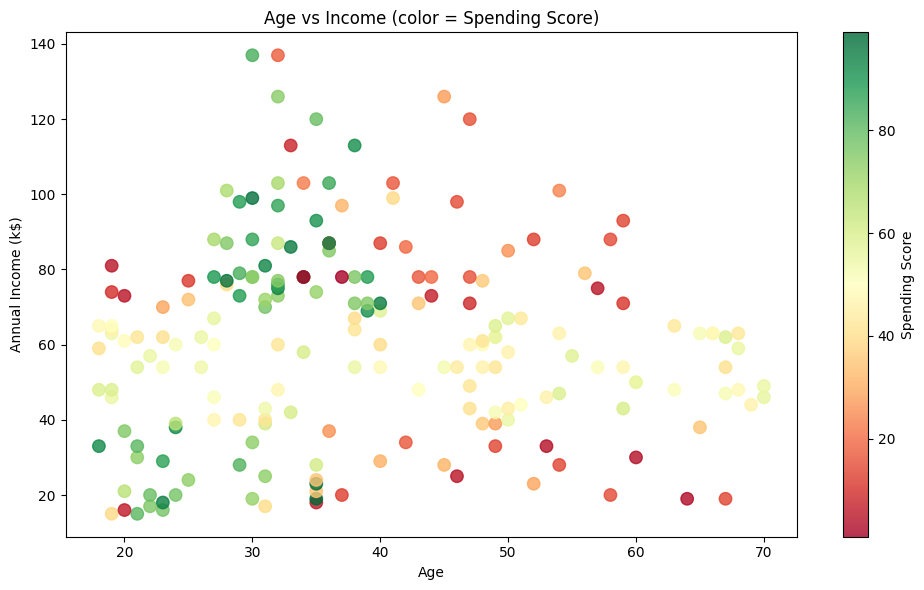

In [3]:
# Correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Age','Income','Spending']].corr(), annot=True,
            fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Boxplots by gender
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Age', 'Income', 'Spending']):
    df.boxplot(column=col, by='Gender', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Features by Gender')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df[['Age','Income','Spending','Gender']], hue='Gender',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot — all features', y=1.02)
plt.show()

# Age vs Income colored by spending
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Age'], df['Income'], c=df['Spending'],
                 cmap='RdYlGn', s=80, alpha=0.8)
plt.colorbar(sc, label='Spending Score')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Age vs Income (color = Spending Score)')
plt.tight_layout()
plt.show()

## 3. Optimal K Selection — Elbow & Silhouette

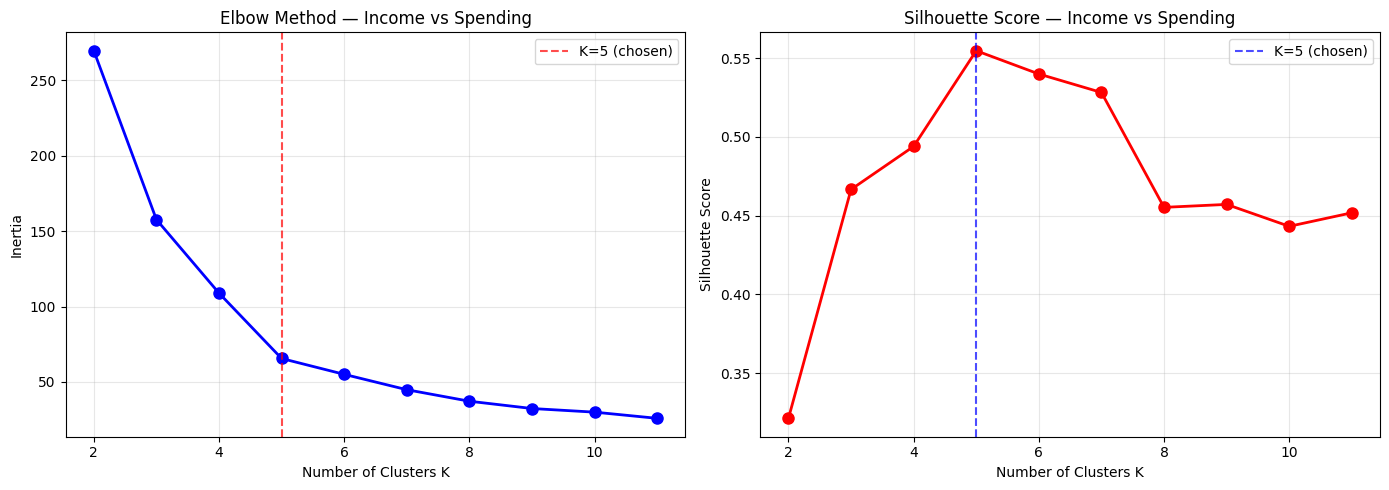

Best K by silhouette: 5
Max silhouette score: 0.5547


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

scaler = StandardScaler()
X = scaler.fit_transform(df[['Income', 'Spending']])

K_range = range(2, 12)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 (chosen)')
axes[0].set_title('Elbow Method — Income vs Spending')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='blue', linestyle='--', alpha=0.7, label='K=5 (chosen)')
axes[1].set_title('Silhouette Score — Income vs Spending')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {K_range[silhouettes.index(max(silhouettes))]}")
print(f"Max silhouette score: {max(silhouettes):.4f}")

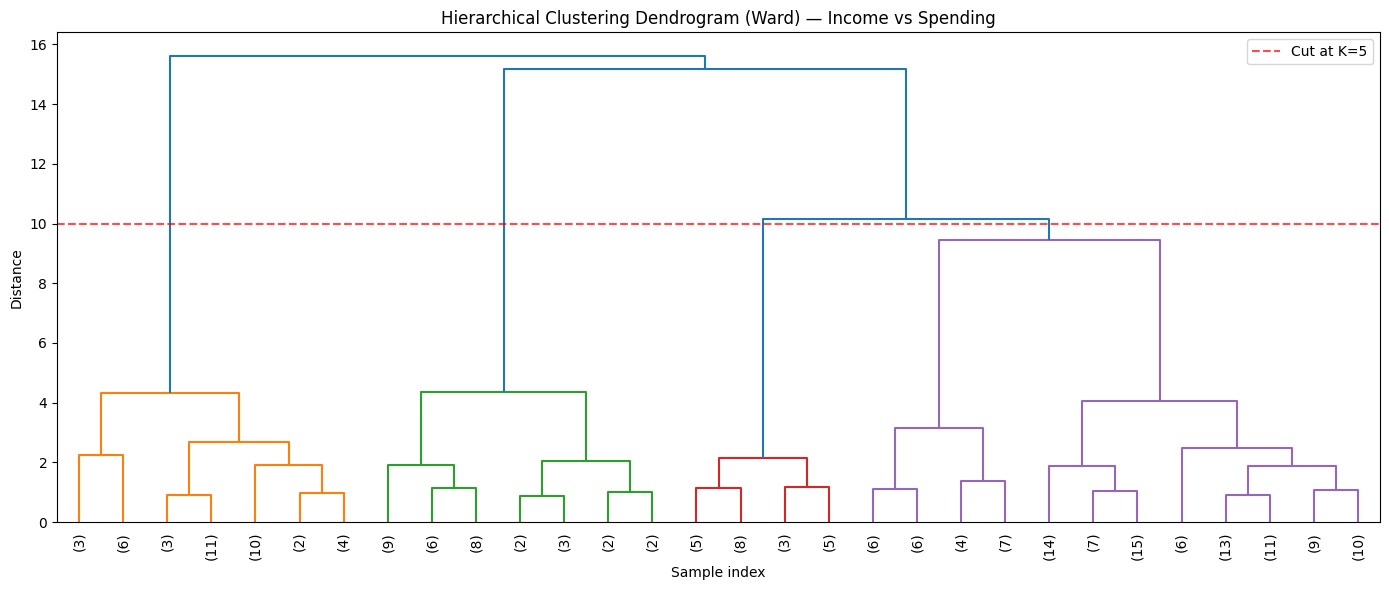

In [5]:
# Hierarchical dendrogram to confirm K=5
plt.figure(figsize=(14, 6))
linked = linkage(X, method='ward')
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=10)
plt.title('Hierarchical Clustering Dendrogram (Ward) — Income vs Spending')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Cut at K=5')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Final Model — KMeans K=5

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

BEST_K = 5
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

sil = silhouette_score(X, df['Cluster'])
db  = davies_bouldin_score(X, df['Cluster'])
ch  = calinski_harabasz_score(X, df['Cluster'])

print(f"Final model — KMeans K={BEST_K}")
print(f"  Silhouette       : {sil:.4f}")
print(f"  Davies-Bouldin   : {db:.4f}  (lower is better)")
print(f"  Calinski-Harabasz: {ch:.1f}   (higher is better)")

# Recover original-scale centroids for plotting
scaler_orig = StandardScaler().fit(df[['Income', 'Spending']])
centroids_orig = scaler_orig.inverse_transform(km.cluster_centers_)

Final model — KMeans K=5
  Silhouette       : 0.5547
  Davies-Bouldin   : 0.5722  (lower is better)
  Calinski-Harabasz: 248.6   (higher is better)


## 5. Cluster Visualizations

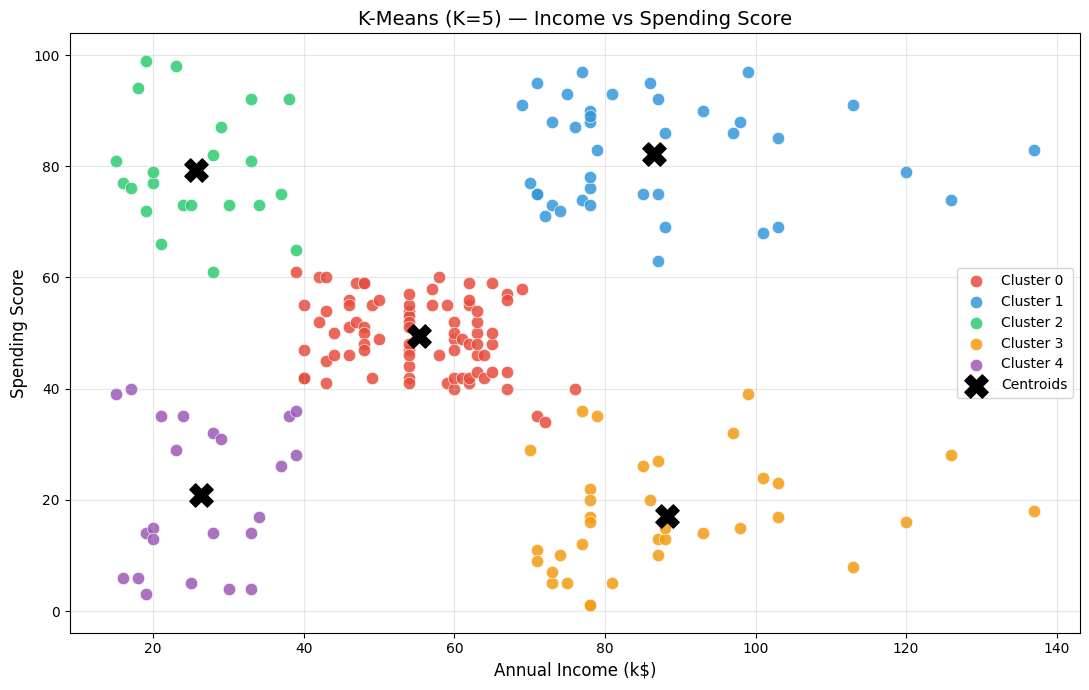

In [7]:
# Income vs Spending — main cluster plot
plt.figure(figsize=(11, 7))
for c in range(BEST_K):
    mask = df['Cluster'] == c
    plt.scatter(df[mask]['Income'], df[mask]['Spending'],
                c=COLORS[c], label=f'Cluster {c}', s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='X', s=280, zorder=5, label='Centroids')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title(f'K-Means (K={BEST_K}) — Income vs Spending Score', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

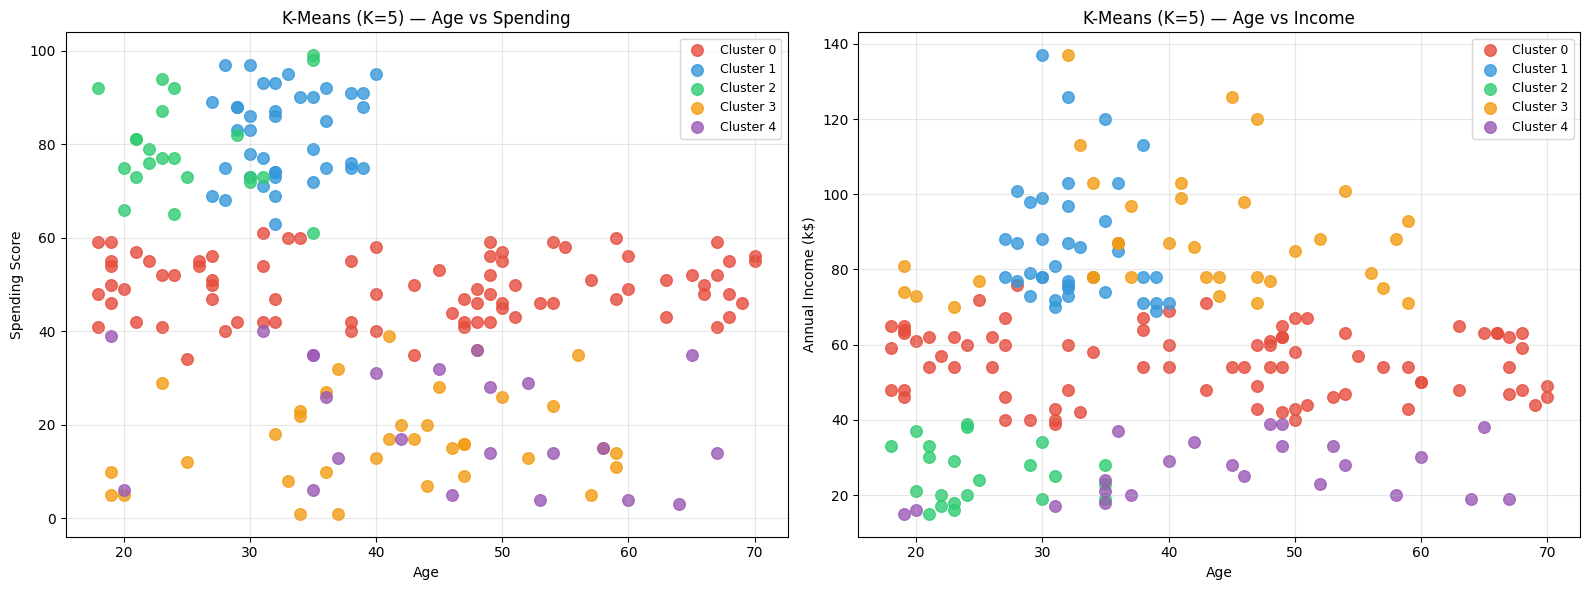

In [8]:
# Age vs Spending & Age vs Income side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(BEST_K):
    mask = df['Cluster'] == c
    axes[0].scatter(df[mask]['Age'], df[mask]['Spending'],
                    c=COLORS[c], label=f'Cluster {c}', s=70, alpha=0.8)
    axes[1].scatter(df[mask]['Age'], df[mask]['Income'],
                    c=COLORS[c], label=f'Cluster {c}', s=70, alpha=0.8)

axes[0].set_xlabel('Age'); axes[0].set_ylabel('Spending Score')
axes[0].set_title(f'K-Means (K={BEST_K}) — Age vs Spending')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Age'); axes[1].set_ylabel('Annual Income (k$)')
axes[1].set_title(f'K-Means (K={BEST_K}) — Age vs Income')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cluster Profiles & Business Interpretation

In [9]:
profile = df.groupby('Cluster')[['Age','Income','Spending']].mean().round(1)
profile['Count']    = df['Cluster'].value_counts().sort_index()
profile['Female_%'] = df.groupby('Cluster')['Gender'].apply(
    lambda x: round((x == 'Female').mean() * 100, 1)
)

SEGMENT_NAMES = {
    0: 'Average Customers',
    1: 'High Income High Spenders',
    2: 'Low Income High Spenders',
    3: 'High Income Low Spenders',
    4: 'Low Income Low Spenders',
}
profile['Segment'] = profile.index.map(SEGMENT_NAMES)

print("Cluster Profiles:")
print(profile.to_string())

Cluster Profiles:
          Age  Income  Spending  Count  Female_%                    Segment
Cluster                                                                    
0        42.7    55.3      49.5     81      59.3          Average Customers
1        32.7    86.5      82.1     39      53.8  High Income High Spenders
2        25.3    25.7      79.4     22      59.1   Low Income High Spenders
3        41.1    88.2      17.1     35      45.7   High Income Low Spenders
4        45.2    26.3      20.9     23      60.9    Low Income Low Spenders


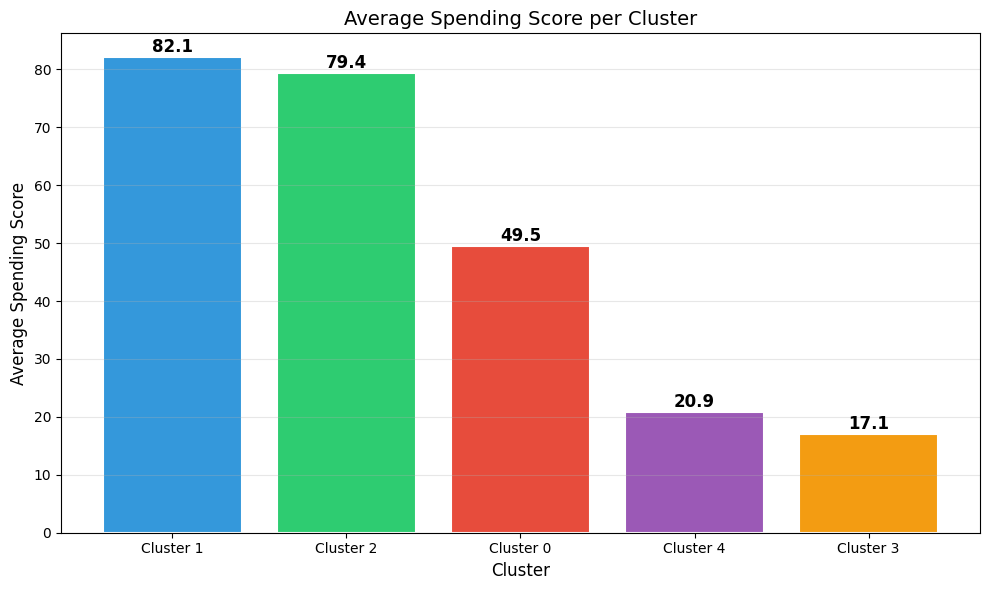

In [10]:
# Average spending per cluster (bonus requirement)
plt.figure(figsize=(10, 6))
avg = df.groupby('Cluster')['Spending'].mean().sort_values(ascending=False)
bars = plt.bar(
    [f'Cluster {i}' for i in avg.index],
    avg.values,
    color=[COLORS[i] for i in avg.index],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Spending Score', fontsize=12)
plt.title('Average Spending Score per Cluster', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Radar Chart — Cluster Profiles

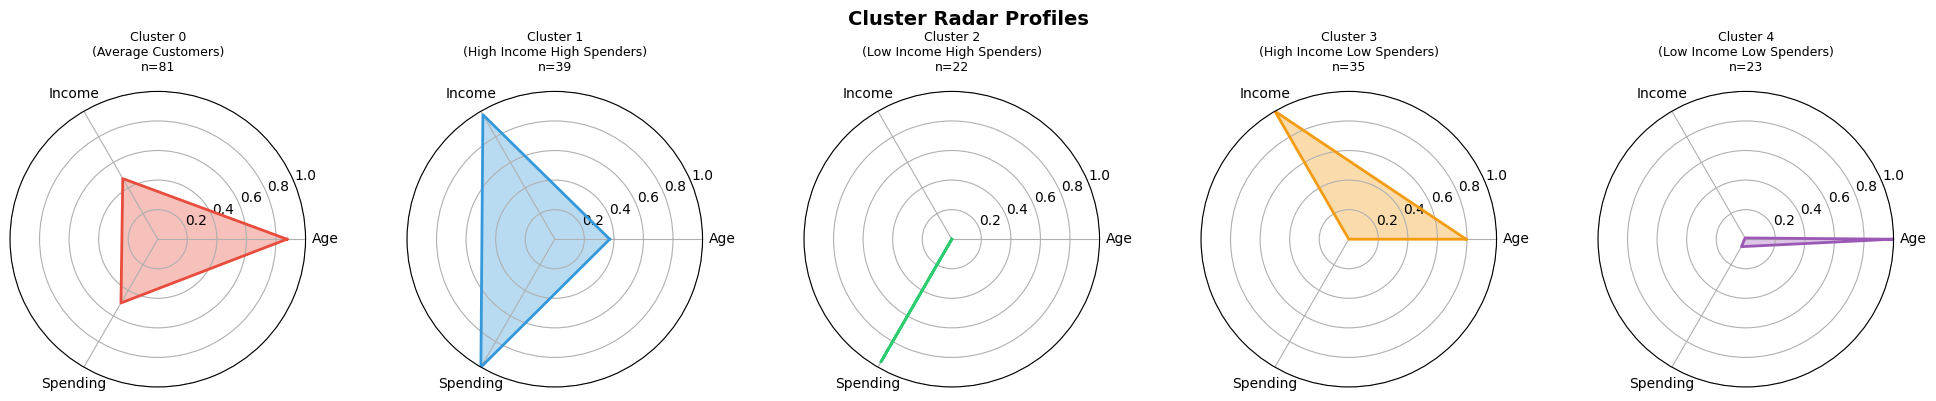

In [12]:
features  = ['Age', 'Income', 'Spending']
norm_prof = (profile[features] - profile[features].min()) /             (profile[features].max() - profile[features].min())
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, BEST_K, figsize=(4 * BEST_K, 4),
                          subplot_kw=dict(polar=True))

for i, ax in enumerate(axes):
    vals = norm_prof.iloc[i].tolist() + [norm_prof.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=COLORS[i], linewidth=2)
    ax.fill(angles, vals, color=COLORS[i], alpha=0.35)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.set_title(
        f"""Cluster {i}
({SEGMENT_NAMES[i]})
n={int(profile["Count"].iloc[i])}""",
        fontsize=9, pad=15
    )
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Radar Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Model Comparison — KMeans vs Agglomerative vs DBSCAN

            Model  Silhouette  Davies-Bouldin  Calinski-H
       KMeans K=5      0.5547          0.5722       248.6
Agglomerative K=5      0.5538          0.5779       244.4
       KMeans K=6      0.5399          0.6546       243.1
       KMeans K=4      0.4939          0.7096       174.6
Agglomerative K=4      0.4926          0.6707       169.7


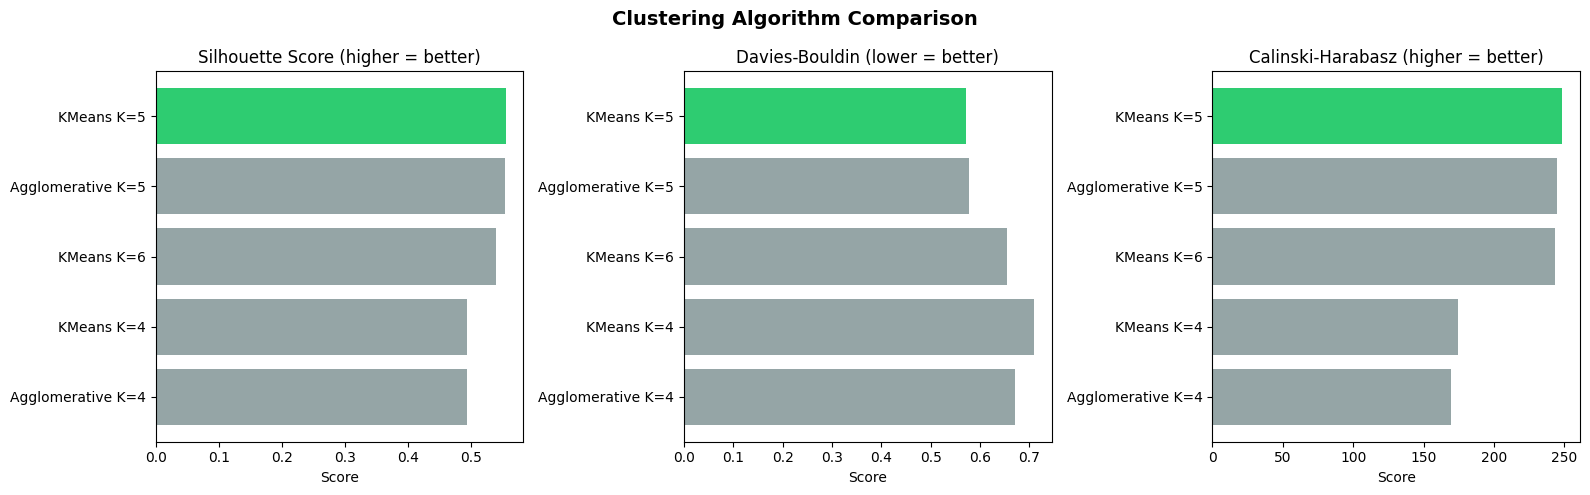

In [13]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

results = []
for name, model in [
    ('KMeans K=5',        KMeans(n_clusters=5, random_state=42, n_init=10)),
    ('KMeans K=4',        KMeans(n_clusters=4, random_state=42, n_init=10)),
    ('KMeans K=6',        KMeans(n_clusters=6, random_state=42, n_init=10)),
    ('Agglomerative K=5', AgglomerativeClustering(n_clusters=5)),
    ('Agglomerative K=4', AgglomerativeClustering(n_clusters=4)),
]:
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    results.append({'Model': name, 'Silhouette': round(sil,4),
                    'Davies-Bouldin': round(db,4), 'Calinski-H': round(ch,1)})

results_df = pd.DataFrame(results).sort_values('Silhouette', ascending=False)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(results_df))]

axes[0].barh(results_df['Model'], results_df['Silhouette'], color=colors_bar)
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('Score')
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['Davies-Bouldin'],
             color=['#2ecc71' if v == results_df['Davies-Bouldin'].min() else '#95a5a6'
                    for v in results_df['Davies-Bouldin']])
axes[1].set_title('Davies-Bouldin (lower = better)')
axes[1].set_xlabel('Score')
axes[1].invert_yaxis()

axes[2].barh(results_df['Model'], results_df['Calinski-H'],
             color=['#2ecc71' if v == results_df['Calinski-H'].max() else '#95a5a6'
                    for v in results_df['Calinski-H']])
axes[2].set_title('Calinski-Harabasz (higher = better)')
axes[2].set_xlabel('Score')
axes[2].invert_yaxis()

plt.suptitle('Clustering Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Bonus — DBSCAN Comparison

DBSCAN — clusters: 2, noise points: 8


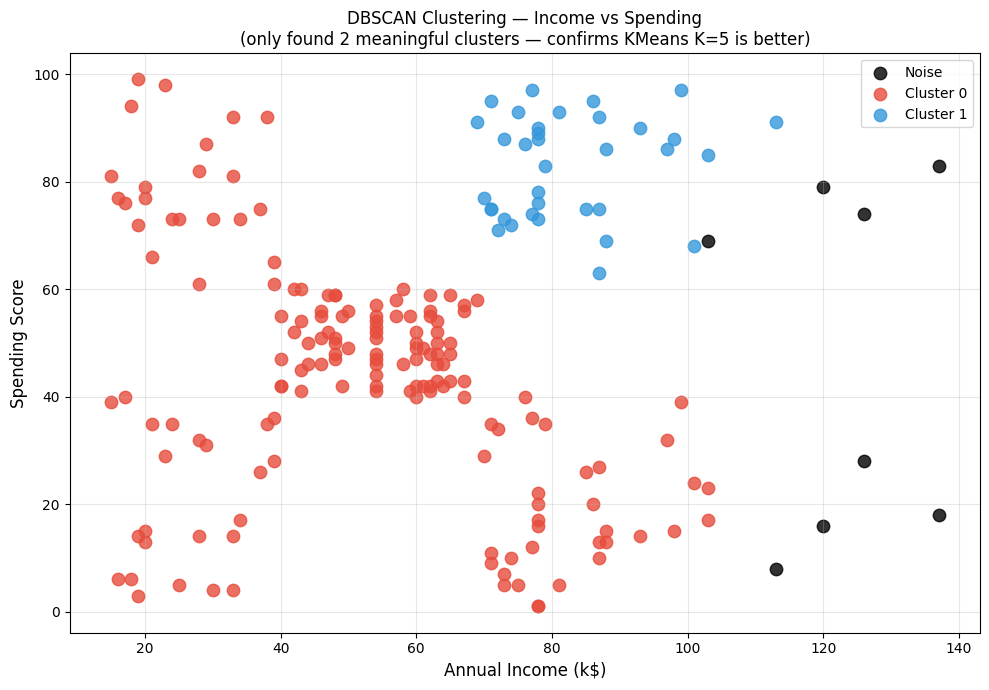

In [15]:
db_labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f"DBSCAN — clusters: {n_clusters}, noise points: {n_noise}")

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(db_labels))
for lbl in unique_labels:
    mask   = db_labels == lbl
    color  = 'black' if lbl == -1 else COLORS[lbl % len(COLORS)]
    label  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(df[mask]['Income'], df[mask]['Spending'],
                c=color, label=label, s=80, alpha=0.8)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('DBSCAN Clustering — Income vs Spending\n(only found 2 meaningful clusters — confirms KMeans K=5 is better)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Summary

In [16]:
print("=" * 60)
print("     CUSTOMER SEGMENTATION — FINAL SUMMARY")
print("=" * 60)

summary = (
    "\nBEST MODEL: KMeans K=5 on Income vs Spending Score\n"
    "  Silhouette       : 0.5547\n"
    "  Davies-Bouldin   : 0.5722\n"
    "  Calinski-Harabasz: 248.6\n"
)
print(summary)

print("CLUSTER PROFILES:")
print("-" * 60)
print(f"  {'Cluster':<10} {'Segment':<32} {'Avg Age':>7} {'Avg Inc':>8} {'Avg Spe':>8} {'Count':>6}")
print("-" * 60)

for c in range(BEST_K):
    row = profile.iloc[c]
    print(f"  {c:<10} {SEGMENT_NAMES[c]:<32} {row['Age']:>7.1f} {row['Income']:>8.1f} {row['Spending']:>8.1f} {int(row['Count']):>6}")

print()
print("KEY FINDINGS:")
print("  1. Income and Spending Score are the strongest clustering signals")
print("  2. Age has weak correlation with spending (-0.33) and income (-0.01)")
print("  3. Gender distribution is nearly equal across all clusters")
print("  4. DBSCAN found only 2 clusters -- KMeans K=5 gives richer segmentation")
print("  5. High income does NOT guarantee high spending (clusters 3 & 4)")
print("  6. Young low-income customers can still be high spenders (cluster 2)")
print("=" * 60)

     CUSTOMER SEGMENTATION — FINAL SUMMARY

BEST MODEL: KMeans K=5 on Income vs Spending Score
  Silhouette       : 0.5547
  Davies-Bouldin   : 0.5722
  Calinski-Harabasz: 248.6

CLUSTER PROFILES:
------------------------------------------------------------
  Cluster    Segment                          Avg Age  Avg Inc  Avg Spe  Count
------------------------------------------------------------
  0          Average Customers                   42.7     55.3     49.5     81
  1          High Income High Spenders           32.7     86.5     82.1     39
  2          Low Income High Spenders            25.3     25.7     79.4     22
  3          High Income Low Spenders            41.1     88.2     17.1     35
  4          Low Income Low Spenders             45.2     26.3     20.9     23

KEY FINDINGS:
  1. Income and Spending Score are the strongest clustering signals
  2. Age has weak correlation with spending (-0.33) and income (-0.01)
  3. Gender distribution is nearly equal across all c